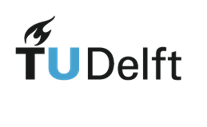




<div style="text-align: center">CIEM5110 – unit 3 – Measurement and Analysis of Vibrations<br>
    Assignment : <b>Experimental modal analysis of a suspended beam</b></div>


<div style="text-align: center"><b>Deadline</b>: 11 April 2025, 23:59 hrs</div>

***

# Background
Beams are commonly used in engineering structures, such as bridges, buildings and railways. Understanding the dynamic behaviour of beams is crucial for the design and health monitoring of related structures. In this assignment, you will perform hammer tests on a suspended beam and investigate its dynamic behaviour by applying the signal processing techniques and experimental modal analysis (EMA) methods covered in the lectures.


# Learning outcomes

This assignment addresses the following learning objectives of unit 3:

2. Interpret and analyse measurements in time and frequency domain (spectral analysis: signal spectrum and frequency response estimation)

3. Extract and interpret modal parameters from spectral estimates (FRF, natural frequencies, mode shapes and damping)

7. Design a measurement set-up for vibration analysis (selection of exciters and of sensor types and placement, data acquisition, selection of filters, sampling schemes)

8. Determine and interpret the uncertainty in spectral, and consequently in modal parameter estimates


# Instructions

You will work in group of two for this assignment. There will be two lab sessions for each group. Please refer to the lab work instructions for a step-by-step guide on how to carry out the lab tests and collect the data.

The assignment consists of three problem sets, each containing multiple exercises. In total, there are **8** exercises that require you to use the data collected during the lab sessions and write Python code to perform calculations and generate figures. Additionally, some exercises will require you to explain and interpret the results. 

Example codes and/or tips will be provided where necessary to guide you through this assignment.Please note that the example codes provided are intended to help you understand the process and are not necessarily the only or most efficient algorithms. You are encouraged to modify them as needed or even develop your own solution. 

After completing the first lab session, you can begin working on Problem sets 1 and 2, which cover signal processing and FRF, respectively. After the second lab session, you can begin working on Problem set 3, which is about modal parameter identification and statistical model updating.

# Resources
The following tools or sources of information are available to help you complete the assignment

•	Lab work instructions (will be handed out during lab sessions)

•	Specification sheets (will be handed out during lab sessions) for
    
    o	Accelerometers
    
    o	Hammer

•	A template in Jupyter notebook for the report

•	References:
   
   o	 P. Zhang, S. Li, A. Núñez, and Z. Li, “Multimodal dispersive waves in free rail: numerical modelling and experimental validation”. Mechanical Systems and Signal Processing, Volume 150, March 2021, 107305. DOI: 10.1016/j.ymssp.2020.107305.
   
   o	 Singiresu S. Rao, “Mechanical vibrations, 6th edition”.Pearson Education Limited, 28 Oct 2017


# Products

You are required to submit a report for this assignment in PDF format. The report should include your Python code, plots, and answers to the questions in the problem sets. A template for the report is available on Brightspace in Jupyter notebook format. Please save or print the notebook as a PDF file before submitting.

# Assessment criteria

Your report will be graded and contributes to 50% of the final grade for unit 3 of module CIEM5110.There are in total 8 exercises for this assignment and they contribute equally to this 50% of the final grade.

The most important aspects of the grading are that your report demonstrates your *understanding* of the concepts covered in the lectures, as well as your ability to *apply* these concepts to real-world problems and *interpret* the results. 

# Supervision & help

The assignment consists of two lab sessions, each lasting for two hours. During these sessions, instructors will be available to provide live feedback and assistance. Additionally, you can post your comments and questions on the Discussion forum on Brightspace. 

# Submission and feedback

Submit your report on Brightspace by **11 April 2025, 23.59 hrs**. Please note that each group only needs to submit one report. This report will be part 2 of your portfolio for Unit 3 of this module.

# Lab test overview
Figure 1 shows a rail beam suspended at two ends. Figure 2 shows the hammer test setup. You will be provided with three one-dimensional accelerometers, an impact hammer, a data acquisition (DAQ) system, and connecting cables. There will be four parallel setups in the lab. The four rail beams are with the same material properties and cross sections, but differ in length.

Lab work instructions will be handed out during lab sessions and provide step-by-step insructions on how to perform the tests.



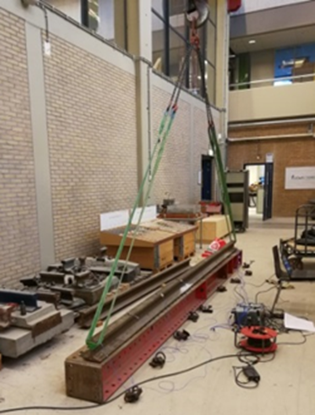
 
              Figure 1. Suspended rail beam.


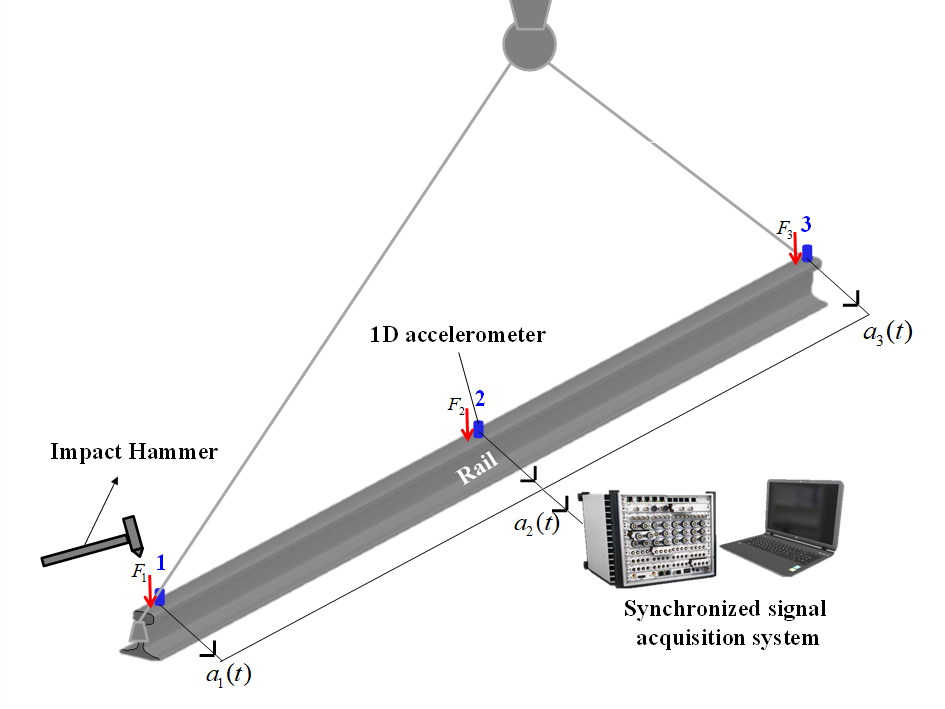
          Figure 2. Hammer test setup. (adapted from P. Zhang, et al., 2020).

# Problem set 1: signal processing
You will use the data collected in Lab Session 1.

### Exercise 1.1. Time domain signals
In Lab Session 1, you were asked to perform hammer tests at three positions and measure the responses from three accelerometers, as shown in Figure 2. We denote the impact forces as $F_i$, where $i$ $(i = 1, 2, 3)$ represents the three positions. We denote the accelerations measured at position $j$ $(j = 1, 2, 3)$ with impact force $F_i$ as $a_{ij}$.

**a**. Plot the hammer force $F_2$ in the time domain. In the lab test, you were instructed to repeat the hammer test at each position at least five times. Choose only one impact from your measurements for the plot. What artifacts in the signal can you observe? Please indicate two artefacts in the plot. (<span style="color:blue">Tip: use `plt.xlim` and `plt.ylim` to control the plot region to identify possible artefacts</span>)

<span style="color:blue">
    
>  **Example code:**

>To answer this question, you will need to read the .csv files from Lab Session 1. Here, let's use one hammer impact at position 3 ($F_3$) as an example to illustrate how to do this.

>The file path and name for this example is "DATA/example_pos31.csv". The file's first four rows include measurement information, and the measurement data starts from row 5 with eight columns. Columns 1, 3, 5, and 7 are the times, while columns 2, 4, 6, and 8 are the measured signals for the hammer force, accelerations at postion 1, 2, and 3, respectively. Note that the columns are separated by ";" and the decimal separators are commas  ",". Note that the column and decimal separators may be different due to system settings. Please check your .csv file and set the parameters accordingly.

>We use the `read_csv` function provided by the Pandas library to read the files and transfer the data to NumPy arrays for further analysis.</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read the .csv file and store the data in a data frame. Use 'sep' argument to define the column separators, 'skiprows' to skip the first four rows, 'decimal' to define the decimal separator. 
data_pos31_df = pd.read_csv("DATA/example_pos31.csv",sep = ";",skiprows = 4, decimal = ",") # you may have sep = "," and decimal = ".". Check your .csv file!

# Transfer the data format to numpy arrays
data_pos31 = data_pos31_df.to_numpy()

# Hammer force at position 3 (F3)
t = data_pos31[:, 0] # time, first column
f_3 = data_pos31[:, 1] # force F3, second column

FileNotFoundError: [Errno 2] No such file or directory: 'DATA/example_pos31.csv'

<span style="color:blue">

> Plot the force in the time domain and adjust the region of the plot using `plt.xlim` and `plt.ylim` if necessary to reveal any artifacts.

</span>

In [ ]:
# Plot F3
plt.plot(t, f_3)
plt.xlabel('Time, s')
plt.ylabel('Hammer force, N')
plt.xlim(3.72,3.725) # use plt.xlim and plt.ylim to control the plot region to identify possible artefacts
plt.show()

**b**. What is the duration of the impulse $F_2$? What is the approximate frequency range that can be well excited by this force based on this impulse duration? (<span style="color:blue">Tip: use `plt.xlim` to zoom in to measure the duration of the impulse</span>)

**c**. During the lab test, you were instructed to repeat the hammer test at each position at least five times. Plot the five repeated impact forces for $F_2$. Then, identify the two impacts with the maximum and minimum peak forces among the five, denoted as $F_{2,max}$ and $F_{2,min}$, respectively. Finally, plot the acceleration $a_{22}$ for these two impacts, denoated as $a_{22,max}$ and $a_{22,min}$, respectively.What are the main differences between the two acceleration signals and why?


<span style="color:blue">

>  **Example code:**

> First, read measurement data from the other impacts.
    
</span>

In [ ]:
# Read the .csv files for the other impacts

# Second impact
data_pos32_df = pd.read_csv("DATA/example_pos32.csv",sep = ";",skiprows = 4, decimal = ",")
data_pos32 = data_pos32_df.to_numpy()
# Third impact
data_pos33_df = pd.read_csv("DATA/example_pos33.csv",sep = ";",skiprows = 4, decimal = ",")
data_pos33 = data_pos33_df.to_numpy()
# Fourth impact
data_pos34_df = pd.read_csv("DATA/example_pos34.csv",sep = ";",skiprows = 4, decimal = ",")
data_pos34 = data_pos34_df.to_numpy()
# Fifth impact
data_pos35_df = pd.read_csv("DATA/example_pos35.csv",sep = ";",skiprows = 4, decimal = ",")
data_pos35 = data_pos35_df.to_numpy()

<span style="color:blue">

> Plot five impact forces in one figure.You may use the `label` argument in `plt.plot` to distinguish between different impacts. Also use `plt.legend()` to show the legend.
    
</span>

In [ ]:
# Plot five impacts in one figure.

plt.figure
plt.plot(data_pos31[:,0],data_pos31[:,1], label = 'impact 1')
plt.plot(data_pos32[:,0],data_pos32[:,1], label = 'impact 2')
plt.plot(data_pos33[:,0],data_pos33[:,1], label = 'impact 3')
plt.plot(data_pos34[:,0],data_pos34[:,1], label = 'impact 4')
plt.plot(data_pos35[:,0],data_pos35[:,1], label = 'impact 5')
plt.xlabel('Time, s')
plt.ylabel('Hammer force, N')
plt.legend()
plt.show()

<span style="color:blue">

> Since the fifth impact has the largest peak force and the second imapct has the lowest peak force, we will plot the accelerations measured at position 2 for these two impacts, which correpsond to conlumn 6 (index 5) of each array.
    
</span>

In [ ]:
plt.figure
plt.plot(data_pos32[:,4],data_pos32[:,5], label = 'impact 2,min')
plt.plot(data_pos35[:,4],data_pos35[:,5], label = 'impact 5,max')
plt.xlabel('Time, s')
plt.ylabel('Acceleration, g')
plt.legend()
plt.show()

### Exercise 1.2. Fourier transform and power spectral density (PSD)
In this exercise, we will evaluate the measured signals in the frequency domain.

**a**. Calculate the Fourier transform of the five hammer impact forces at $F_2$. Use the full length of the signal without windowing. Plot the positive part of the double-sided Fourier amplitude spectrums of the five forces in one figure in log-log scale. Explain the similarities and differences between different force spectrums.

<span style="color:blue">

>  **Example code:**

> Because we will calcute the Fourier transforms of five forces, it is a good practice to arrange the five force signals in an array using `np.stack`.
    
</span>

In [ ]:
forces = np.stack((data_pos31[:,1],data_pos32[:,1],data_pos33[:,1],data_pos34[:,1],data_pos35[:,1]),axis=-1)
forces.shape # check the shape of the array. It should be an N by 5 array, where N is the signal length.

<span style="color:blue">

> Now cacluate the Fourier transform of the forces using `scipy.fft`. We will also use `scipy.fftfreq` to calcualte the frequencies of the Fourier spectrum.
    
</span>

In [ ]:
from scipy.fft import fft,fftfreq
sf = 25600;
N_sig = forces.shape[0] # number of data points in the signal
freq = fftfreq(N_sig, 1/sf)[:N_sig//2] # fourier frequencies

# Calculate the fft of each force and plot them in one figure
plt.figure
for ii in range(5):
    fft_force = fft(forces[:,ii],axis = -1)
    # plot the positive part of the fourier spectrum in log-log scale
    plt.loglog(freq, 2.0/N_sig * np.abs(fft_force[0:N_sig//2]))


#plt.xlim(10, 10000)
plt.xlabel('Frequency, Hz')
plt.ylabel('Magnitude, []') # Note: decide the magnitude unit yourself
plt.title('FFT of impact forces')
plt.show()



**b**. The natural frequencies (in rad/s) of a beam can be calculated based on an analytical beam model as (S.Rao, 2017)

$$
\omega_n=(\beta_n l)^2 \sqrt{\frac{E I}{\rho A l^4}}
$$

where $E$ is the Young's modulus, $I$ is the moment of inertia of the beam cross-section, $\rho$ is the density, $A$ is the area of the beam cross-section, $l$ is the length of the beam, and $\beta_n$ can be determined by the boundary conditions of the beam for each mode $n$.

The rails used in the lab sessions are of type 54E1 and have the following properties:

- Young's modulus: 210 GPa
- Density: 7850 kg/m^3
- Moment of inertia: 2337.9 cm^4
- Cross-section area: 69.77 cm^2

The values of $\beta_n l$ for the free-free boundary conditions are given below

$$
\begin{aligned}
& \beta_1 l=4.730041 \\
& \beta_2 l=7.853205 \\
& \beta_3 l=10.995608 \\
& \beta_4 l=14.137165
\end{aligned}
$$


Calculate the first three natural frequencies (in Hz, and thus you should calculate $\omega_n / 2 \pi$, $n = 1,2,3$) of the beam you tested on. Note that you need to measure the length of the beam $l$.

In [ ]:
import math
E = 210e9
rho = 7850
L = 3.259
I = 2337.9e-8
Area = 69.77e-4
betaL = np.array([4.730041, 7.853205, 10.995608, 14.1317165])

for ii in betaL:
    natural_freq = ii ** 2 * math.sqrt(E * I / (rho * Area * (L**4))) / (2 * np.pi)
    print(natural_freq)

**c**. Calculate the Fourier transform of $a_{22,max}$ and $a_{22,min}$. Use the full length of the signal without windowing. Plot the positive part of the double-sided Fourier amplitude spectrums of the two accelerations in one figure in log-log scale. Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies. Explain the similarities and differences between the two spectrums.(<span style="color:blue">Tip: follow the same steps described in the example code above.</span>)

**d**. The periodogram is an estimate of the PSD of the signal. Calculate the Welch periodogram of the PSD of $a_{22,max}$. Plot the periodogram in log-log scale. 

- Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies.

- Use a rectangular window with different lengths to see its effect. (set the argument `nperseg` with different values)

- Compare the Welch periodogram  and Fourier spectrum of $a_{22,max}$,and explain the main differences between the two.

<span style="color:blue">

>  **Example code:**
    Use `scipy.sigal.welch` to calcualte the Welch periodogram.

</span>

In [ ]:
from scipy import signal
N_fft = N_sig # number of data point for FFT. Here the same length as the signal
N_overlap = 0 # number of overlap. Here no overlap between windows
N_window = N_sig // 5 # number of window length, change this value to see its effect

# Calculate the Welch estimate using a rectanguler window
fxx, pxx = signal.welch(data_pos35[:,5], sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)

#
plt.figure
plt.loglog(fxx, pxx)
plt.xlim(50, 2000)
plt.xlabel('Frequency, Hz')
plt.ylabel('PSD, []') # Decide the unit for PSD yourself
plt.show()

### Exercise 1.3. Signal alignment, windowing and zero-padding

**a. (Force window)** In Exercise 1.1.a, we showed the artefacts presented in the force signals. To remove the artefacts,we need to set the forces outside the impulse to zeros. To do this, first define a trigger force level and get the indices of the triggered forces.Then design a rectangular window with value one for the triggered indices and value zero for the rest. (This is also called a force window) Finally, apply the force window to the force signal. Following the steps above, choose one impact force, apply a force window, and plot the windowed and orginal signals in the same figure to show the differences.

<span style="color:blue">

>  **Example code:**

> We use $F_{2,max}$ to demonstrate how to apply the force window.
    
</span>

In [ ]:
# Define a trigger force of 5 N
force_trigger = 5

# Get the boolean indices of the forces that are larger than the trigger force
idx_boolean = data_pos35[:,1] > force_trigger

# Find the indices of triggered forces
idx_triggered = np.where(idx_boolean)[0]

# Define a rectangular window
rec_win = np.zeros(len(data_pos35[:,1]))
rec_win[idx_triggered,] = 1
f_max_windowed = np.multiply(data_pos35[:,1], rec_win)

# Plot the forces
plt.figure
plt.plot(data_pos35[:,0],data_pos35[:,1], label = 'impact 5, original')
plt.plot(data_pos35[:,0],f_max_windowed, label = 'impact 5, windowed')
plt.xlabel('Samples')
plt.ylabel('Hammer force, N')
plt.xlim((2.755,2.760))
plt.ylim((-10,100)) # use plt.xlim and plt.ylim to zoom in to a certain region to show the differences
plt.legend()
plt.show()

**b. (Signal alignment)** In Exercise 1.1.c, we showed that the forces and accelerations for different impacts are not aligned in the time domain. To align the signals, you can truncate each force signal from a few (e.g., 10) samples before the index of the first triggered force. Show the aligned force and acceleration sigals.Please use $F_{2,max}$ ($a_{22,max}$) and $F_{2,min}$ ($a_{22,min}$) as examples.

<span style="color:blue">

>  **Example code:**

> We use $F_{2,max}$ ($a_{22,max}$) and $F_{2,min}$ ($a_{22,min}$) to demonstrate how to tructate the signals and align them.
    
</span>

In [ ]:
# Truncate the signal 10 samples before the first index of the triggered force
f_max_truncated = f_max_windowed[idx_triggered[0]-10:,]
acc_max_truncated = data_pos35[idx_triggered[0]-10:,5]

# Do the same for the impact force with the minimum peak

idx_boolean = data_pos32[:,1] > force_trigger
idx_triggered = np.where(idx_boolean)[0]
rec_win = np.zeros(len(data_pos32[:,1]))
rec_win[idx_triggered,] = 1
f_min_windowed = np.multiply(data_pos32[:,1], rec_win)
f_min_truncated = f_min_windowed[idx_triggered[0]-10:,]
acc_min_truncated = data_pos32[idx_triggered[0]-10:,5]

# Plot the two forces in one figure

plt.figure
plt.plot(f_min_truncated, label = 'impact 2, min')
plt.plot(f_max_truncated, label = 'impact 5, max')
plt.xlabel('Samples')
plt.ylabel('Hammer force, N')
plt.xlim((0,50))
plt.legend()
plt.show()

# Plot the two accelerations in one figure

plt.figure
plt.plot(acc_min_truncated, label = 'impact 2, min')
plt.plot(acc_max_truncated, label = 'impact 5, max')
plt.xlabel('Samples')
plt.ylabel('Acceleration,g')
plt.legend()
plt.show()

**c. (Exponential window)**. Apply an exponential window to aligned $a_{22,max}$.The exponential window can be calculated as $w(t)=e^{(-\beta t)}$. Compare the windowed and orignal signals with different $\beta$ values. Explain why an exponential window is necessry and what its effect for the modal analysis later on.

<span style="color:blue">

>  **Example code:**</span>

In [ ]:
# Creat time instances for the window
t_acc = np.arange(0,1 / sf * len(acc_max_truncated), 1 / sf)

# Creat the window
import math
beta = 1 # change the beta value to see its effect
temp = t_acc * beta
exp_win = np.zeros(len(t_acc))
for idx_temp, x_temp in enumerate(t_acc):
    exp_win[idx_temp,] = math.exp(x_temp * beta * (-1))

# Apply the window to the acceleration.
acc_max_windowed = np.multiply(acc_max_truncated, exp_win)

# Plot the two accelerations

plt.figure
plt.plot(t_acc, acc_max_truncated, label = 'Original')
plt.plot(t_acc, acc_max_windowed, label = 'Windowed')
plt.xlabel('Time, s')
plt.ylabel('Acceleration,g')
plt.legend()
plt.show()

**d. (Zero-padding)** Caculate the Welch periodogram of the windowed $a_{22,max}$.This time zero-pad the signal to 40 seconds by setting the `nfft` argument in `signal.welch` to the correct value. Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies. Compare this periodogram with the one in Exercise 1.2.d. What are the main differences and why?

<span style="color:blue">

>  **Example code:**
    
</span>

In [ ]:
N_fft = 40 * sf # number of data point for FFT.Here we zero-pad the signal to 40 seconds
N_overlap = 0 # number of overlap. Here no overlap between windows
N_window = len(acc_max_windowed) # number of window length

# Calculate the Welch estimate using a rectanguler window
fxx, pxx = signal.welch(acc_max_windowed, sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)

#
plt.figure
plt.loglog(fxx, pxx)
plt.xlim(50, 2000)
plt.xlabel('Frequency, Hz')
plt.ylabel('PSD, []') # Decide the unit for PSD yourself
plt.show()

# Problem set 2: frequency response functions (FRF)
You will use the data collected in Lab Session 1.

###  Exercise 2.1. H1 estimator of FRF

In this exercise, we will calculate the H1 estimator of the FRF based on the equation

$$
\hat{H}_{xy}(\omega)=\frac{S_{x y}(\omega)}{S_{x x}(\omega)}
$$

where $S_{x y}(\omega)$ is the cross-spectral density (CSD) of the input $x$ and output $y$, and $S_{x x}(\omega)$ is the PSD of the input.Thus, $\hat{H}_{xy}(\omega)$ denotes the H1 estimator of the FRF with hammer impact at position $x$ and accelerations measured at $y$. In this excercise, we will calcuate $\hat{H}_{22}(\omega)$.

**a**. The main idea is to take the averages of the experimental results to remove the noise in the signals. For this, we need to pre-process the five force signals at $F_2$ and five acceleration signals at $a_{2 2}$.The steps are

- For the each impact force at $F_2$,
 - Apply a force window,
 - Align the signals: use a trigger level to determine where to truncate the each signal,
 - Apply an exponential window $w(t)=e^{(-\beta t)}$, with a $\beta$ value of your choice.
- For the corresponding acceleration signal measured at $a_{22}$
 - First align each acceleration signal using the same shift applied to the corresponding impact force.
 - Apply the same exponential window as for the impact force.
- Zero-pad the force and acceleration signals to 20 seconds.

(<span style="color:blue">Tip: refer to the example code provided in Exercise 1.3 for the steps above.</span>)

- Re-arrange the five force signals in one array and five acceleration signals in one array.Plot the two arrays

Plot the processed input (force) signal and output (acceleration) signal.

<span style="color:blue">

>  **Example code:**
    
> We use the $F_3$ and $a_{33}$ signals as examples. 
    
</span>

In [ ]:
# Get the five force and acceleration signals
forces = np.stack((data_pos31[:,1],data_pos32[:,1],data_pos33[:,1],data_pos34[:,1],data_pos35[:,1]),axis=-1)
accs = np.stack((data_pos31[:,7],data_pos32[:,7],data_pos33[:,7],data_pos34[:,7],data_pos35[:,7]),axis=-1)

# Define a trigger force of 5 N
force_trigger = 5

# Define a matrix to store 20 s long signal for five impacts
acc_pad = np.zeros((20 * sf,5))
impulse_pad = np.zeros((20 * sf,5))

# Loop through each impact
for ii in range(5):
    # Get one impact
    impulse = forces[:,ii]
    acc = accs[:,ii]
    
    # Truncate the signals
    idx_boolean = impulse > force_trigger
    idx_triggered = np.where(idx_boolean)[0]
    rec_win = np.zeros(len(impulse))
    rec_win[idx_triggered,] = 1
    impulse_windowed = np.multiply(impulse, rec_win)
    impulse_truncated = impulse_windowed[idx_triggered[0]-10:,]
    acc_truncated = acc[idx_triggered[0]-10:,]

    # Creat time instances for the window
    t_acc = np.arange(0,1 / sf * len(acc_truncated), 1 / sf)

    # Creat the exp window
    beta = 10 # change the beta value to see its effect
    temp = t_acc * beta
    exp_win = np.zeros(len(t_acc))
    for idx_temp, x_temp in enumerate(t_acc):
        exp_win[idx_temp,] = math.exp(x_temp * beta * (-1))

    # Apply the exp window
    acc_windowed = np.multiply(acc_truncated, exp_win)
    impulse_truncated_exp = np.multiply(impulse_truncated, exp_win)

    # Zero-pad the signals to 20 s long
    pad_after = 20 * sf - len(acc_truncated)
    acc_pad[:,ii] = np.pad(acc_windowed,(0,pad_after),'constant',constant_values = (0,0))
    impulse_pad[:,ii] = np.pad(impulse_truncated_exp,(0,pad_after),'constant',constant_values = (0,0))

# Rearrange the force signals in one array and acceleration signals in one array
acc_processed = np.hstack((acc_pad[:,0],acc_pad[:,1],acc_pad[:,2],acc_pad[:,3],acc_pad[:,4]))
impulse_processed = np.hstack((impulse_pad[:,0],impulse_pad[:,1],impulse_pad[:,2],impulse_pad[:,3],impulse_pad[:,4]))


In [ ]:
# Plot the results
plt.figure
plt.plot(impulse_processed)
plt.xlabel('Samples')
plt.ylabel('Hammer force, N')
plt.show()

plt.figure
plt.plot(acc_processed)
plt.xlabel('Samples')
plt.ylabel('Accelerations, g')
plt.show()

**b**. Calculate the PSD, CSD and H1 estimator of the FRF ($\hat{H}_{22}(\omega)$) using the processed input (force) signals and output (acceleration) signals.Plot the amplitude and phase angle of ($\hat{H}_{22}(\omega)$).

(<span style="color:blue">Tips: 1. Use `scipy.sigal.welch` to calcualte the estimate of PSD and `scipy.sigal.csd` to caculate the estimate of CSD, both using Welch's method. Because we want to average the signals from five impacts, we will use a rectangular window (`window='boxcar'`) with the length of the padded signals (20 seconds in this case, so `nperseg = 20 * sf`), and without overlapping (`noverlap = None`). Change the value of `nfft` to see the effect of zero-padding the signals for a longer period of time. 2. Use `numpy.angle` to calculate the phase angle</span>)

In [ ]:
N_fft = 80 * sf # number of data point for FFT.Here we zero-pad the signal to 80 seconds
N_overlap = 0 # number of overlap. Here no overlap between windows
N_window = 20 * sf # number of window length

# Calculate the Welch estimate using a rectanguler window
fxx, Sxx = signal.welch(impulse_processed, sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)
fxy, Sxy = signal.csd(impulse_processed, acc_processed, sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)

H1 = np.divide(Sxy,Sxx)


In [ ]:
#
plt.figure
plt.loglog(fxx, np.abs(H1))
plt.xlim(50, 2000)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magitude, []') # Decide the unit for FRF amplitude yourself
plt.show()

plt.figure
plt.semilogx(fxx, np.angle(H1))
plt.xlim(50, 2000)
plt.ylim(-3.14,3.14)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF phase, []') # Decide the unit for FRF phase yourself
plt.show()

### Exercise 2.2. FRF matrix
**a.** How many FRFs can you obtain from the data collected in Lab Session 1? Which are the driving-point FRFs and which are the transfer FRFs?

**b**. For the hammer impact at position 1, caluclate the plot the driving-point FRF $\hat{H}_{11}(\omega)$ and one tranfer FRF of your choice (<span style="color:blue">Tip: follow the same steps described in Exercise 2.1.</span>). Explain

- The main differences between $\hat{H}_{11}(\omega)$ and $\hat{H}_{22}(\omega)$, and

- The main differences between the driving-point and transfer FRFs

<span style="color:blue">

>  **Example code:**
    
> We re-use the code in Excercise 2.1 to calculate $H_{32}$, with $F_3$ as input and $a_{32}$ as output. 
    
</span>

In [ ]:
# Exactly the same code as in Excercise 2.1. Only change the output acceleration signals.

# Get the five force and acceleration signals
forces = np.stack((data_pos31[:,1],data_pos32[:,1],data_pos33[:,1],data_pos34[:,1],data_pos35[:,1]),axis=-1)
# Here change the acceleration signal from column 8 (a_33)to column 6 (index 5) (a_32)
accs = np.stack((data_pos31[:,5],data_pos32[:,5],data_pos33[:,5],data_pos34[:,5],data_pos35[:,5]),axis=-1)

# Define a trigger force of 5 N
force_trigger = 5

# Define a matrix to store 20 s long signal for five impacts
acc_pad = np.zeros((20 * sf,5))
impulse_pad = np.zeros((20 * sf,5))

# Loop through each impact
for ii in range(5):
    # Get one impact
    impulse = forces[:,ii]
    acc = accs[:,ii]
    
    # Truncate the signals
    idx_boolean = impulse > force_trigger
    idx_triggered = np.where(idx_boolean)[0]
    rec_win = np.zeros(len(impulse))
    rec_win[idx_triggered,] = 1
    impulse_windowed = np.multiply(impulse, rec_win)
    impulse_truncated = impulse_windowed[idx_triggered[0]-10:,]
    acc_truncated = acc[idx_triggered[0]-10:,]

    # Creat time instances for the window
    t_acc = np.arange(0,1 / sf * len(acc_truncated), 1 / sf)

    # Creat the exp window
    beta = 10 # change the beta value to see its effect
    temp = t_acc * beta
    exp_win = np.zeros(len(t_acc))
    for idx_temp, x_temp in enumerate(t_acc):
        exp_win[idx_temp,] = math.exp(x_temp * beta * (-1))

    # Apply the exp window
    acc_windowed = np.multiply(acc_truncated, exp_win)
    impulse_truncated_exp = np.multiply(impulse_truncated, exp_win)

    # Zero-pad the signals to 20 s long
    pad_after = 20 * sf - len(acc_truncated)
    acc_pad[:,ii] = np.pad(acc_windowed,(0,pad_after),'constant',constant_values = (0,0))
    impulse_pad[:,ii] = np.pad(impulse_truncated_exp,(0,pad_after),'constant',constant_values = (0,0))

# Rearrange the force signals in one array and acceleration signals in one array
acc_processed = np.hstack((acc_pad[:,0],acc_pad[:,1],acc_pad[:,2],acc_pad[:,3],acc_pad[:,4]))
impulse_processed = np.hstack((impulse_pad[:,0],impulse_pad[:,1],impulse_pad[:,2],impulse_pad[:,3],impulse_pad[:,4]))

# # Plot the results
# plt.figure
# plt.plot(impulse_processed)
# plt.xlabel('Samples')
# plt.ylabel('Hammer force, N')
# plt.show()

# plt.figure
# plt.plot(acc_processed)
# plt.xlabel('Samples')
# plt.ylabel('Accelerations, g')
# plt.show()

In [ ]:
N_fft = 80 * sf # number of data point for FFT.Here we zero-pad the signal to 80 seconds
N_overlap = 0 # number of overlap. Here no overlap between windows
N_window = 20 * sf # number of window length

# Calculate the Welch estimate using a rectanguler window
fxx, Sxx = signal.welch(impulse_processed, sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)
fxy, Sxy = signal.csd(impulse_processed, acc_processed, sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)

H1_32 = np.divide(Sxy,Sxx)

In [ ]:
#
plt.figure
plt.loglog(fxx, np.abs(H1_32),label='H32')
plt.loglog(fxx, np.abs(H1),label='H33')

plt.xlim(50, 2000)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magitude, []') # Decide the unit for FRF amplitude yourself
plt.legend()
plt.show()

# Problem set 3: Modal parameter identification and statistic model updating.
You will use the data collected in Lab Session 2. You will also use an analytical beam model.

### Exercise 3.1. Natural frequencies and damping ratio
In Lab Session 2, you were asked to design an experiment to obtain the modal parameters of the first three bending modes of the beam using a roving-hammer scheme. Suppose you have chosen $N$ positions for the hammer impacts with a fixed accelerometer position.

**a**. Use a figure to show the $N$ measurement positions. Calculate the $N$ FRFs and plot them in one figure. (<span style="color:blue">Tip: follow the same steps described in Exercise 2.1.</span>)

**b**. Identify the first three natural frequencies of the beam bending modes from one of the FRFs you showed in Exercise 3.1.a (choose one as you wish). For this, you can use the peak-picking method. That is to select the frequencies where the peaks of the FRF magnitude occur. Compare the first three natural frequencies obtained from the FRF with those calculated from the analytical model (Exercise 1.2.b) and discuss what the possilbe causes for the discrepencies are.

<span style="color:blue">

>  **Example code:**
    
> Use the function `scipy.signal.find_peaks` to locate the peak frequecies.We use the H1 estimator obtained in Exercise 2.1 as an example.There are a couple of arguments you can use to control the number of peaks the algorithm detects. Here we set the height of the peak so that only peaks that are higher than this value (0.02 in this case)are detected.You need to change this setting for your case and may also need to use other arguments. Please refer the the documentation of `scipy.signal.find_peaks` to see its detailed usage.
    
> Alternatively, you can simply use `numpy.maximum` in a certain frequency range to detect the peaks.
    
</span>

In [ ]:
peaks,_ = signal.find_peaks(np.abs(H1),height=0.02)

In [ ]:
plt.figure
frf = np.abs(H1)
plt.loglog(fxx, np.abs(H1))
plt.plot(fxx[peaks], frf[peaks], "x") 
plt.xlim(50, 600)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magitude, []') # Decide the unit for FRF amplitude yourself
plt.show()
print("The first three natural frequencies are", fxx[peaks[1]], "Hz,", fxx[peaks[2]],"Hz,", fxx[peaks[3]], "Hz.")

**c**. Estimate the damping ratio of the first three natural frequencies using the same FRF as in Exercise 3.1.b. For this, you can use the half-power bandwidth method.

<span style="color:blue">

>  **Example code:**
    
> In this example, we estimate the damping ratio for the first natural frequency at 95.4 Hz. First, determine the FRF magitude at half-power bandwidth, that is 3 dB drop from the FRF peak at 95.4 Hz. It can be calcuated as $\frac{1}{\sqrt{2}} \times$ FRF peak
</span>

In [ ]:
# Calculate the FRF magnitude with 3db drop
peak_3db = frf[peaks[1]] * (1/math.sqrt(2))

# Visualize the result 
plt.figure
frf = np.abs(H1)
plt.semilogy(fxx, np.abs(H1))
plt.plot(fxx[peaks], frf[peaks], "x") 
plt.axhline(y=peak_3db, color='r', linestyle='-')
plt.xlim(90, 100)
plt.ylim(5e-3,1e-1)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magitude, []') # Decide the unit for FRF amplitude yourself
plt.show()

<span style="color:blue">

> Subsequently, we need to find the bounding frequencies of the half-power bandwidth (denoted as $\omega_1$ and $\omega_2$), that is the intersections between the red line and the blue FRF curve shown in the figure above.
    
</span>

In [ ]:
# First calculate the differences in magnitude between FRF curve and the 
# Take the absolute value and multipy it by -1
diff_3db = np.abs(frf - peak_3db) * (-1)

# Show the diff_3db. 
# This is for illustration purpose. You may not need to plot this in your answers
plt.figure
plt.plot(fxx,diff_3db)
plt.xlim(90,100)
plt.ylim(-0.05,0.05)
plt.show()

In [ ]:
# Find the two peaks in the figure above around the first natural frequency
peaks_3db,_ = signal.find_peaks(diff_3db, height=-0.001)

# Plot the intersections
# This is for illustration purpose. You may not need to plot this in your answers
plt.figure
plt.semilogy(fxx, np.abs(H1))
plt.plot(fxx[peaks], frf[peaks], "x") 
plt.axhline(y=peak_3db, color='r', linestyle='-')
plt.plot(fxx[peaks_3db], frf[peaks_3db], "o") 
plt.xlim(90, 100)
plt.ylim(5e-3,1e-1)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magitude, []') # Decide the unit for FRF amplitude yourself
plt.show()

<span style="color:blue">

> Now calculate the half-power bandwidth as
    
$$
\delta \omega=\omega_2-\omega_1,
$$
    
> and calucate the damping ratio
    $$
    \zeta_n=\frac{\Delta_n}{2 \omega_n},
    $$
    
> where $\Delta_n=2 \zeta_n \omega_n=\delta \omega$.
    
> Remember to correct the damping ratio due to the exponential window
    $$
    \zeta_{c, r}=\zeta_{m, r}-\frac{\beta}{2 \pi f_r}
    $$
</span>

In [ ]:
# calculate the distance between the two bounding frequencies
omega_1 = fxx[peaks_3db[0]]
omega_2 = fxx[peaks_3db[1]]
delta_omega = omega_2 - omega_1

# Estimate the damping ratio
dr = delta_omega / (2 * fxx[peaks[0]])
print("The damping ratio estimated from FRF for the first mode is ", dr)

# Correct the artificial damping caused by the exponential window
dr_c = dr - beta / (2 * np.pi * fxx[peaks[0]])
print("The corrected damping ratio for the first mode is ", dr_c)

                                    

### Exercise 3.2. Mode shapes

For this exercise, you will use the FRFs calculated in Exercise 3.1.a to determine the mode shape of the first mode. You have $N$ FRFs which were obtained from hammer impacts at $N$ positions. The FRF at position $p$ is denoted as $H(\omega,p)$, $p = 1,2,...,N$. To calculate the modal amplitude of each mode $n$ for each $H(\omega,p)$, you can use the following formula:

$$
a_n \approx \frac{H\left(\omega_n, p\right)}{i Q_n}
$$


where $i$ is the imaginary unit, and $Q_n$ is the quality factor of the $n$th mode, which can be calculated as $Q_n=\frac{\omega_n}{\Delta_n}=\frac{1}{2 \zeta_n}$. Now calculate $a_n$ for each FRF shown in Exercise 3.1.a and for mode $n = 1$. 

**a.** Plot $a_1$ at $N$ positions to show the first mode shape. Note that you should scale the modal amplitude $a_1$ so that its maximum amplitude is 100. (<span style="color:blue">Tip: use the example code provided in Exercise 3.1 to obtain $\omega_1$ and $\zeta_1$ for each FRF </span>)

**b.** The mode shapes of a free-free beam can be calculated analytically as

$$
\begin{aligned}
W_n(x)= & C_n\left[\sin \beta_n x+\sinh \beta_n x\right. \\
& \left.+\alpha_n\left(\cos \beta_n x+\cosh \beta_n x\right)\right]
\end{aligned}
$$
where
$$
\alpha_n=\left(\frac{\sin \beta_n l-\sinh \beta_n l}{\cosh \beta_n l-\cos \beta_n l}\right)
$$

$C_n$ is a constant scale factor. The values of $\beta_n l$ are given below

$$
\begin{aligned}
& \beta_1 l=4.730041 \\
& \beta_2 l=7.853205 \\
& \beta_3 l=10.995608 \\
& \beta_4 l=14.137165
\end{aligned}
$$

Calculate and show the first three analytical mode shapes of a free-free beam. Note that you should scale each mode shape $W_n(x)$ so that its maximum amplitude is 100. You can use the scale factor $C_n$ for this. (Refer to Exercise 1.2.b for the length of the beam.)

**c.** Plot the measured (Exercise 3.2.a) and analytical (Exercise 3.2.b) model shapes for the first mode in one figure. Caculate the Modal Assurance Criterion (MAC) value between the two mode shapes. Explain what this MAC value indicates.

$$
\mathrm{MAC}_{r s}=\frac{\left|\phi_r^{\mathrm{T}^*} \phi_s\right|^2}{\left(\phi_r^{\mathrm{T}^*} \phi_r\right)\left(\phi_s^{\mathrm{T}^*} \phi_s\right)}
$$


### Exercise 3.3. Analysis of measurement uncertainty （optional）

Compare the FRFs measured with hits at ideal and deviated locations and analyze how the hammer hitting positions may influence the measurement results.